<a href="https://colab.research.google.com/github/Kaneko23/pdi-trabalho-m1/blob/main/Trabalho_M1_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto M1.1 – Operações Pontuais e Filtragem Espacial
Disciplina: Processamento de Imagens — Prof. Felipe Viel
Curso: Ciência da Computação — UNIVALI

Integrante: Kauê Patrick de Brito

## 0. Setup

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import urllib.request
import os
import cv2  # usado apenas no item 5.a (cv2.Canny), conforme pedido no enunciado

DATA_DIR = "dataset"
os.makedirs(DATA_DIR, exist_ok=True)

BASE_URL = "https://raw.githubusercontent.com/VielF/ColabProjects/main/dataset/ImgTrabM1/"

FILES = [
    "Clear.jpg", "Degraded.jpg", "barbara.jpg", "bell.jpg", "bellbw.jpg",
    "bg.jpg", "bg1.jpg", "blur.jpg", "box.png", "cameraman.png", "canyon.png",
    "clearbw.jpg", "contrast.jpg", "cubes.png", "eye.png", "eyeref.png",
    "fg.jpg", "fg1.jpg", "gamma-corr.png", "lena.jpg", "lena1.jpg", "lena2.jpg",
    "lena3.jpg", "mri.png", "noir.png", "part1.png", "part2.png", "part3.png",
    "part4.png", "pots_flash.jpg", "pots_no_flash.jpg", "q4.png", "q7_1.jpeg",
    "q7_2.jpg", "quantize.jpg", "sky.png",
]

for f in FILES:
    dest = os.path.join(DATA_DIR, f)
    if not os.path.exists(dest):
        try:
            urllib.request.urlretrieve(BASE_URL + f, dest)
        except Exception as e:
            print(f"Falha ao baixar {f}: {e}")


In [5]:
def carregar_rgb(caminho):
    return np.array(Image.open(caminho).convert("RGB"))

def carregar_cinza(caminho):
    return np.array(Image.open(caminho).convert("L"))

def mostrar(imgs, titulos=None, cmap=None, figsize=(12, 4)):
    n = len(imgs)
    fig, axs = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axs = [axs]
    for i, ax in enumerate(axs):
        ax.imshow(imgs[i], cmap=cmap)
        if titulos:
            ax.set_title(titulos[i])
        ax.axis("off")
    plt.tight_layout()
    plt.show()

def caminho(nome):
    return os.path.join(DATA_DIR, nome)


## 1.a — Cor mais frequente

Cor mais frequente: RGB(np.uint8(255), np.uint8(255), np.uint8(253)) -- aparece 851 vezes


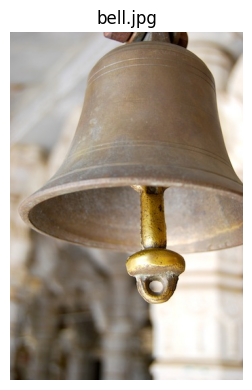

In [6]:
def cor_mais_frequente(img_rgb):
    pixels = img_rgb.reshape(-1, 3)
    cores, contagens = np.unique(pixels, axis=0, return_counts=True)
    idx = np.argmax(contagens)
    return tuple(cores[idx]), contagens[idx]


img_teste = carregar_rgb(caminho("bell.jpg"))
cor, qtd = cor_mais_frequente(img_teste)
print(f"Cor mais frequente: RGB{cor} -- aparece {qtd} vezes")
mostrar([img_teste], ["bell.jpg"])


## 1.b/1.c — mergeImage

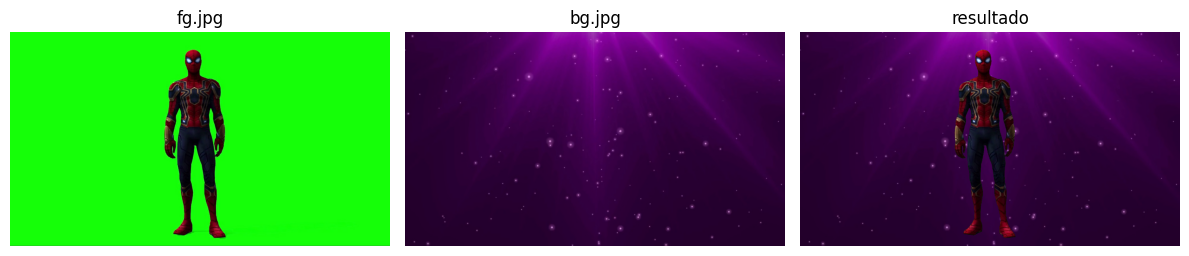

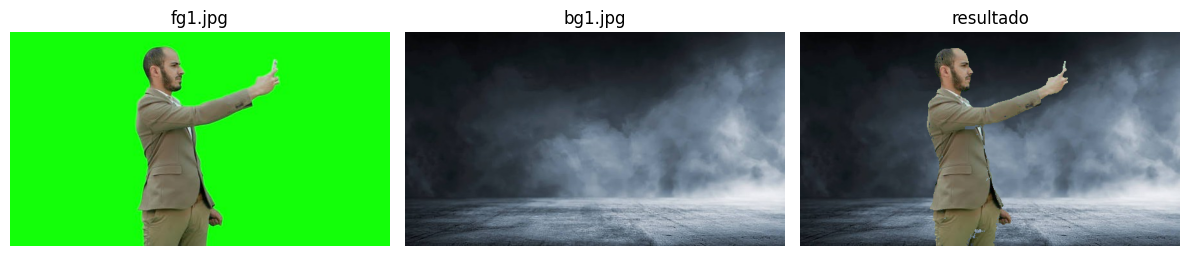

In [7]:
def rgb_para_hsv(img_rgb):
    img = img_rgb.astype(np.float64) / 255.0
    r, g, b = img[..., 0], img[..., 1], img[..., 2]

    cmax = np.max(img, axis=-1)
    cmin = np.min(img, axis=-1)
    delta = cmax - cmin

    h = np.zeros_like(cmax)
    mask = delta != 0

    r_is_max = (cmax == r) & mask
    g_is_max = (cmax == g) & mask & ~r_is_max
    b_is_max = (cmax == b) & mask & ~r_is_max & ~g_is_max

    h[r_is_max] = (60 * (((g[r_is_max] - b[r_is_max]) / delta[r_is_max]) % 6))
    h[g_is_max] = (60 * (((b[g_is_max] - r[g_is_max]) / delta[g_is_max]) + 2))
    h[b_is_max] = (60 * (((r[b_is_max] - g[b_is_max]) / delta[b_is_max]) + 4))

    s = np.where(cmax == 0, 0, delta / np.where(cmax == 0, 1, cmax))
    v = cmax
    return np.stack([h, s, v], axis=-1)


def mergeImage(fg, bg, h_min=70, h_max=170, s_min=0.25, v_min=0.20):
    if fg.shape[:2] != bg.shape[:2]:
        bg = np.array(Image.fromarray(bg).resize((fg.shape[1], fg.shape[0])))

    hsv = rgb_para_hsv(fg)
    h, s, v = hsv[..., 0], hsv[..., 1], hsv[..., 2]
    mascara_fundo = (h >= h_min) & (h <= h_max) & (s >= s_min) & (v >= v_min)

    resultado = fg.copy()
    resultado[mascara_fundo] = bg[mascara_fundo]
    return resultado


fg1 = carregar_rgb(caminho("fg.jpg"))
bg1 = carregar_rgb(caminho("bg.jpg"))
res1 = mergeImage(fg1, bg1)
mostrar([fg1, bg1, res1], ["fg.jpg", "bg.jpg", "resultado"])

fg2 = carregar_rgb(caminho("fg1.jpg"))
bg2 = carregar_rgb(caminho("bg1.jpg"))
res2 = mergeImage(fg2, bg2)
mostrar([fg2, bg2, res2], ["fg1.jpg", "bg1.jpg", "resultado"])


## 2.a — BitQuantizeImage

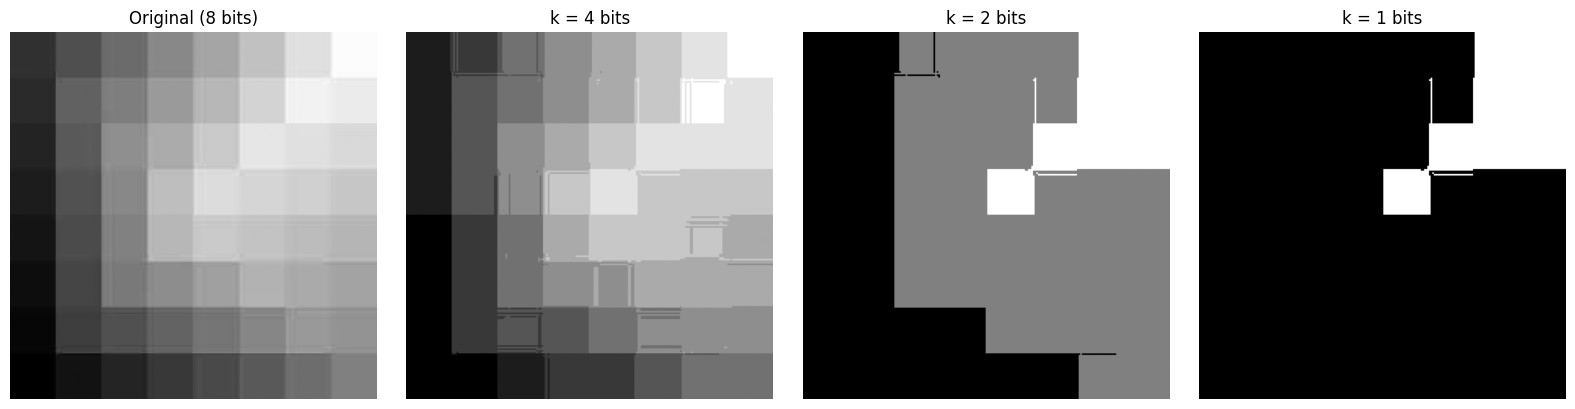

In [8]:
def BitQuantizeImage(im, k):
    assert 1 <= k <= 8
    niveis = 2 ** k
    passo = 256 / niveis

    im_f = im.astype(np.float64)
    indice_nivel = np.floor(im_f / passo)
    indice_nivel = np.clip(indice_nivel, 0, niveis - 1)
    return (indice_nivel * passo + passo / 2).astype(np.uint8)


img_quant = carregar_cinza(caminho("quantize.jpg"))
resultados = [img_quant]
titulos = ["Original (8 bits)"]
for k in [4, 2, 1]:
    resultados.append(BitQuantizeImage(img_quant, k))
    titulos.append(f"k = {k} bits")

mostrar(resultados, titulos, cmap="gray", figsize=(16, 4))


## 2.b — Planos de bits

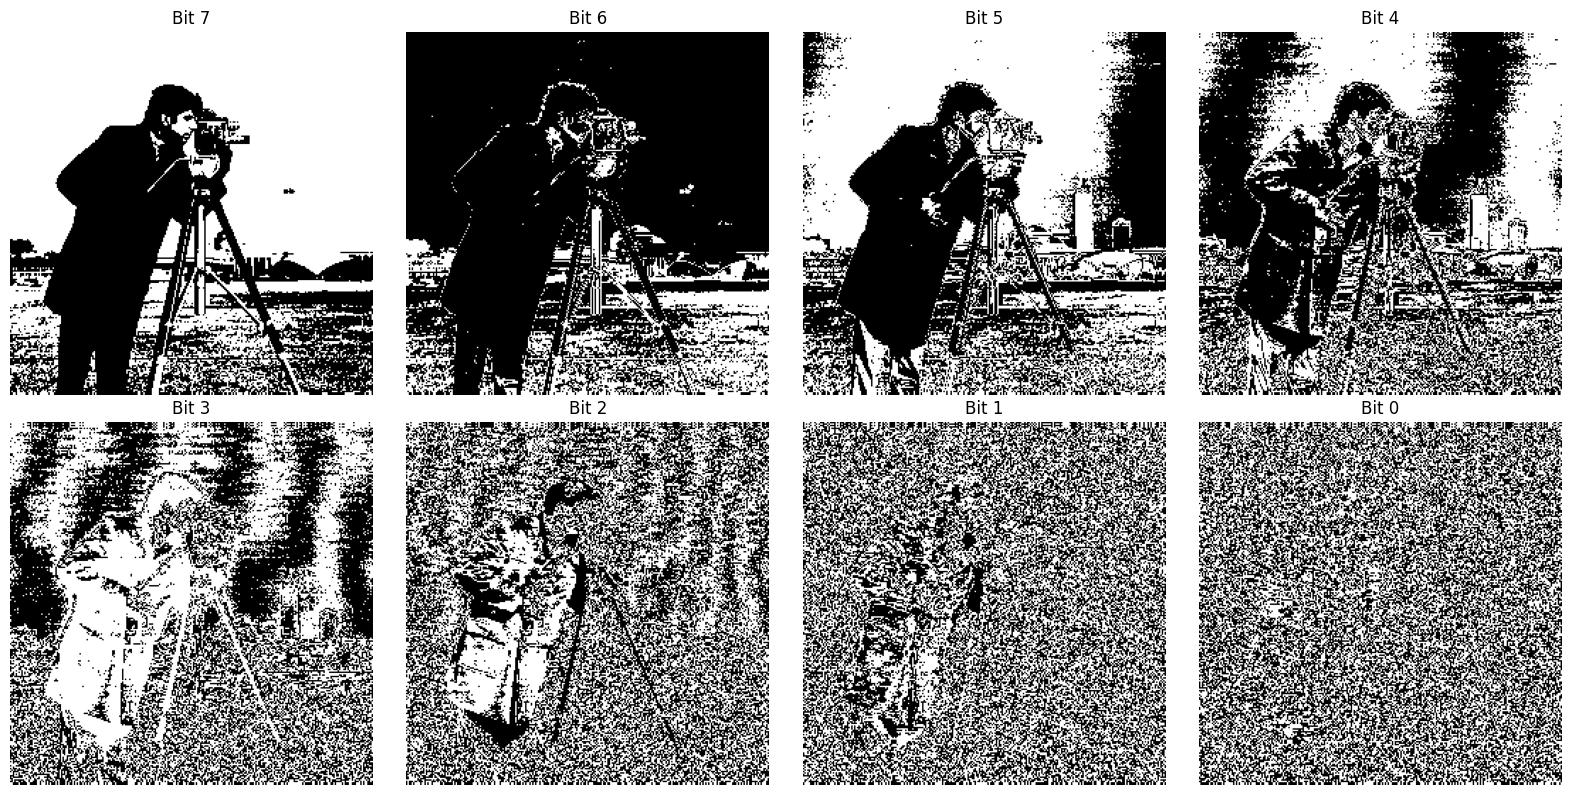

In [9]:
def planos_de_bits(im):
    planos = []
    for i in range(7, -1, -1):
        plano = (im >> i) & 1
        planos.append(plano * 255)
    return planos


img_cameraman = carregar_cinza(caminho("cameraman.png"))
planos = planos_de_bits(img_cameraman)

fig, axs = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axs.flat):
    bit = 7 - i
    ax.imshow(planos[i], cmap="gray")
    ax.set_title(f"Bit {bit}")
    ax.axis("off")
plt.tight_layout()
plt.show()


## 2.c — Operações em lena1/lena2/lena3

Observações:
- lena1.jpg: aspecto granulado, poucos tons -> planos de bits menos significativos (LSBs) mantidos.
- lena2.jpg: mantém a forma geral mas com poucos tons -> quantização / MSBs mantidos.
- lena3.jpg: mistura de bordas fortes e regiões planas -> subconjunto intermediário de planos de bits.

In [ ]:
imgs_lena = {
    "lena.jpg (original)": carregar_cinza(caminho("lena.jpg")),
    "lena1.jpg": carregar_cinza(caminho("lena1.jpg")),
    "lena2.jpg": carregar_cinza(caminho("lena2.jpg")),
    "lena3.jpg": carregar_cinza(caminho("lena3.jpg")),
}

mostrar(list(imgs_lena.values()), list(imgs_lena.keys()), cmap="gray", figsize=(16, 4))

fig, axs = plt.subplots(1, 4, figsize=(16, 3))
for ax, (nome, im) in zip(axs, imgs_lena.items()):
    ax.hist(im.ravel(), bins=256, range=(0, 255))
    n_niveis = len(np.unique(im))
    ax.set_title(f"{nome}\n{n_niveis} níveis únicos")
plt.tight_layout()
plt.show()


## 3. Questões Diversas

**a)** Zerar os bits MSB restringe os pixels a uma faixa estreita e baixa de intensidade — o histograma fica concentrado perto de 0 e a estrutura principal da imagem se perde.

**b)** Zerar os bits LSB equivale a quantizar a imagem — o histograma fica esparso (só múltiplos de um degrau aparecem), mas a estrutura visual se mantém.

**c)** Cálculo do tempo de transmissão:

In [ ]:
largura, altura = 512, 512
bits_por_pixel_transmitidos = 1 + 8 + 1  # start + dado + stop

total_bits = largura * altura * bits_por_pixel_transmitidos

for nome, baud in [("56K baud", 56_000), ("3000K baud", 3_000_000)]:
    tempo_s = total_bits / baud
    print(f"{nome}: {total_bits:,} bits / {baud:,} baud = {tempo_s:.4f} s")


## 4.a — Equalização de histograma

In [ ]:
def equalizar_histograma(im):
    hist, _ = np.histogram(im.ravel(), bins=256, range=(0, 256))
    cdf = hist.cumsum()
    cdf_normalizada = (cdf - cdf.min()) * 255 / (cdf.max() - cdf.min())
    cdf_normalizada = cdf_normalizada.astype(np.uint8)
    return cdf_normalizada[im]


img_escolhida = carregar_cinza(caminho("contrast.jpg"))
eq1 = equalizar_histograma(img_escolhida)
eq2 = equalizar_histograma(eq1)

mostrar([img_escolhida, eq1, eq2], ["Original", "Equalizada 1x", "Equalizada 2x"], cmap="gray")

fig, axs = plt.subplots(1, 3, figsize=(14, 3))
for ax, (nome, im) in zip(axs, [("Original", img_escolhida), ("Eq 1x", eq1), ("Eq 2x", eq2)]):
    ax.hist(im.ravel(), bins=256, range=(0, 255))
    ax.set_title(nome)
plt.tight_layout()
plt.show()


**Observação:** a segunda equalização gera imagem praticamente idêntica à primeira — o processo é aproximadamente idêmpotente.

## 4.b — Transformação de histograma (histogram matching)

In [ ]:
def transformar_histograma(origem, referencia):
    def cdf_de(im):
        hist, _ = np.histogram(im.ravel(), bins=256, range=(0, 256))
        cdf = hist.cumsum().astype(np.float64)
        return cdf / cdf[-1]

    cdf_origem = cdf_de(origem)
    cdf_ref = cdf_de(referencia)

    mapeamento = np.zeros(256, dtype=np.uint8)
    for g_o in range(256):
        diffs = np.abs(cdf_ref - cdf_origem[g_o])
        mapeamento[g_o] = np.argmin(diffs)

    return mapeamento[origem]


partes = {f"part{i}": carregar_cinza(caminho(f"part{i}.png")) for i in range(1, 5)}
brilhos = {k: v.mean() for k, v in partes.items()}
print("Brilho médio de cada quadrante:", brilhos)

ordenado = sorted(brilhos, key=brilhos.get)
mais_escura, *_, mais_clara = ordenado
print(f"Mais escura: {mais_escura} | Mais clara: {mais_clara}")


In [ ]:
# Par 1: histogramas semelhantes
diffs_par = sorted(
    ((abs(brilhos[a] - brilhos[b]), a, b)
     for i, a in enumerate(partes) for b in list(partes)[i+1:]),
)
_, im_a_nome, im_b_nome = diffs_par[0]
im_a, im_b = partes[im_a_nome], partes[im_b_nome]
resultado_semelhante = transformar_histograma(im_a, im_b)
mostrar([im_a, im_b, resultado_semelhante],
        [f"Origem ({im_a_nome})", f"Referência ({im_b_nome})", "Resultado"], cmap="gray")

# Par 2: imagem escura -> clara
origem_escura = partes[mais_escura]
ref_clara = partes[mais_clara]
resultado_escura_para_clara = transformar_histograma(origem_escura, ref_clara)
mostrar([origem_escura, ref_clara, resultado_escura_para_clara],
        [f"Origem ({mais_escura})", f"Referência ({mais_clara})", "Resultado"], cmap="gray")

# Par 3: imagem clara -> escura
resultado_clara_para_escura = transformar_histograma(ref_clara, origem_escura)
mostrar([ref_clara, origem_escura, resultado_clara_para_escura],
        [f"Origem ({mais_clara})", f"Referência ({mais_escura})", "Resultado"], cmap="gray")


## 5.a — Detector de Canny

In [ ]:
bell = carregar_cinza(caminho("bell.jpg"))
cubes = carregar_cinza(caminho("cubes.png"))

combinacoes_bell = [(50, 150), (100, 200), (150, 250)]
combinacoes_cubes = [(50, 150), (100, 200), (30, 100)]

fig, axs = plt.subplots(2, len(combinacoes_bell), figsize=(14, 6))
for i, (mn, mx) in enumerate(combinacoes_bell):
    axs[0, i].imshow(cv2.Canny(bell, mn, mx), cmap="gray")
    axs[0, i].set_title(f"bell.jpg minVal={mn}, maxVal={mx}")
    axs[0, i].axis("off")
for i, (mn, mx) in enumerate(combinacoes_cubes):
    axs[1, i].imshow(cv2.Canny(cubes, mn, mx), cmap="gray")
    axs[1, i].set_title(f"cubes.png minVal={mn}, maxVal={mx}")
    axs[1, i].axis("off")
plt.tight_layout()
plt.show()

melhor_bell = (100, 200)
melhor_cubes = (50, 150)
print("Melhores parâmetros -> bell:", melhor_bell, "| cubes:", melhor_cubes)


## 5.b — Roberts, Prewitt, Sobel, Laplaciano vs. Canny

In [ ]:
def add_padding(im, ph, pw):
    n, m = im.shape
    im_pad = np.zeros((n + ph * 2, m + pw * 2))
    im_pad[ph:n + ph, pw:m + pw] = im
    return im_pad


def convolucao2d(im, kernel):
    im = im.astype(np.float64)
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2
    im_pad = add_padding(im, ph, pw)
    saida = np.zeros_like(im)
    kernel_rot = np.flipud(np.fliplr(kernel))

    H, W = im.shape
    for i in range(H):
        for j in range(W):
            regiao = im_pad[i:i+kh, j:j+kw]
            saida[i, j] = np.sum(regiao * kernel_rot)
    return saida


def magnitude_gradiente(im, kx, ky):
    gx = convolucao2d(im, kx)
    gy = convolucao2d(im, ky)
    mag = np.sqrt(gx**2 + gy**2)
    return np.clip(mag, 0, 255).astype(np.uint8)


ROBERTS_X = np.array([[0, 1], [-1, 0]])
ROBERTS_Y = np.array([[1, 0], [0, -1]])

PREWITT_X = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
PREWITT_Y = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]])

SOBEL_X = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
SOBEL_Y = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]])

LAPLACIANO_4 = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]])
LAPLACIANO_8 = np.array([[1, 1, 1], [1, -8, 1], [1, 1, 1]])


In [ ]:
barbara = carregar_cinza(caminho("barbara.jpg"))

roberts = magnitude_gradiente(barbara, ROBERTS_X, ROBERTS_Y)
prewitt = magnitude_gradiente(barbara, PREWITT_X, PREWITT_Y)
sobel = magnitude_gradiente(barbara, SOBEL_X, SOBEL_Y)
laplaciano4 = np.clip(np.abs(convolucao2d(barbara, LAPLACIANO_4)), 0, 255).astype(np.uint8)
laplaciano8 = np.clip(np.abs(convolucao2d(barbara, LAPLACIANO_8)), 0, 255).astype(np.uint8)
canny_barbara = cv2.Canny(barbara, 100, 200)

mostrar(
    [barbara, roberts, prewitt, sobel, laplaciano4, laplaciano8, canny_barbara],
    ["Original", "Roberts", "Prewitt", "Sobel", "Laplaciano 4", "Laplaciano 8", "Canny"],
    cmap="gray", figsize=(20, 4)
)


**Observações:** Roberts (kernel 2x2) é mais sensível a ruído e gera bordas mais finas e descontínuas. Sobel dá mais peso à linha/coluna central, sendo um pouco mais robusto que Prewitt. O Laplaciano (2ª derivada) realça bordas em todas as direções mas é o mais sensível a ruído. O Canny gera bordas mais finas e contínuas por aplicar supressão de não-máximos e histerese.

## 5.c — Efeito de ruído gaussiano

In [ ]:
def adicionar_ruido_gaussiano(im, media=0, desvio=15):
    ruido = np.random.normal(media, desvio, im.shape)
    im_ruidosa = im.astype(np.float64) + ruido
    return np.clip(im_ruidosa, 0, 255).astype(np.uint8)


barbara_ruidosa = adicionar_ruido_gaussiano(barbara, desvio=15)

roberts_r = magnitude_gradiente(barbara_ruidosa, ROBERTS_X, ROBERTS_Y)
prewitt_r = magnitude_gradiente(barbara_ruidosa, PREWITT_X, PREWITT_Y)
sobel_r = magnitude_gradiente(barbara_ruidosa, SOBEL_X, SOBEL_Y)
laplaciano_r = np.clip(np.abs(convolucao2d(barbara_ruidosa, LAPLACIANO_8)), 0, 255).astype(np.uint8)
canny_r = cv2.Canny(barbara_ruidosa, 100, 200)

mostrar(
    [barbara_ruidosa, roberts_r, prewitt_r, sobel_r, laplaciano_r, canny_r],
    ["Com ruído", "Roberts", "Prewitt", "Sobel", "Laplaciano", "Canny"],
    cmap="gray", figsize=(18, 4)
)


**Observação:** o Laplaciano degrada mais com ruído (amplifica alta frequência). Sobel/Prewitt ficam mais sujos mas reconhecíveis. O Canny se sai relativamente melhor por suavizar a imagem internamente antes do gradiente.

## 6. Filtragem High-Boost

In [ ]:
def filtro_media(im, tamanho_janela):
    k = np.ones((tamanho_janela, tamanho_janela)) / (tamanho_janela ** 2)
    return convolucao2d(im, k)


def high_boost(im, tamanho_janela=3, A=1.5):
    suavizada = filtro_media(im, tamanho_janela)
    mascara = im.astype(np.float64) - suavizada
    saida = im.astype(np.float64) + A * mascara
    return np.clip(saida, 0, 255).astype(np.uint8)


bell_cinza = carregar_cinza(caminho("bell.jpg"))
configs = [(3, 1.0), (3, 2.0), (5, 1.5), (7, 1.5)]
resultados_hb = [bell_cinza] + [high_boost(bell_cinza, j, a) for j, a in configs]
titulos_hb = ["Original"] + [f"janela={j}, A={a}" for j, a in configs]

mostrar(resultados_hb, titulos_hb, cmap="gray", figsize=(20, 4))


**Observações:** janela maior suaviza mais forte, deixando o realce mais grosseiro. `A` maior aumenta o realce, mas satura em valores muito altos.

In [ ]:
cameraman_cinza = carregar_cinza(caminho("cameraman.png"))
resultados_hb2 = [cameraman_cinza] + [high_boost(cameraman_cinza, j, a) for j, a in configs]
mostrar(resultados_hb2, titulos_hb, cmap="gray", figsize=(20, 4))


**Diferença bilateral x high-boost:** high-boost é linear e realça alta frequência em toda a imagem, inclusive ruído. O bilateral é não-linear, suaviza regiões homogêneas mas preserva bordas fortes (pondera por distância espacial e por diferença de intensidade).

## 7. Filtragem Bilateral

In [ ]:
def add_padding_replicado(im, r):
    """Padding por replicação de borda, implementado manualmente."""
    n, m = im.shape
    im_pad = np.zeros((n + 2 * r, m + 2 * r))
    im_pad[r:n + r, r:m + r] = im
    im_pad[:r, r:m + r] = im[0:1, :]
    im_pad[n + r:, r:m + r] = im[-1:, :]
    im_pad[:, :r] = im_pad[:, r:r+1]
    im_pad[:, m + r:] = im_pad[:, m + r - 1:m + r]
    return im_pad


def filtro_bilateral(im, tamanho_janela=5, sigma_espacial=3.0, sigma_intensidade=25.0):
    im = im.astype(np.float64)
    r = tamanho_janela // 2
    im_pad = add_padding_replicado(im, r)

    y, x = np.mgrid[-r:r+1, -r:r+1]
    peso_espacial = np.exp(-(x**2 + y**2) / (2 * sigma_espacial**2))

    H, W = im.shape
    saida = np.zeros_like(im)
    for i in range(H):
        for j in range(W):
            janela = im_pad[i:i+tamanho_janela, j:j+tamanho_janela]
            centro = im[i, j]
            peso_intensidade = np.exp(-((janela - centro)**2) / (2 * sigma_intensidade**2))
            peso_total = peso_espacial * peso_intensidade
            saida[i, j] = np.sum(peso_total * janela) / np.sum(peso_total)
    return np.clip(saida, 0, 255).astype(np.uint8)


def redimensionar_se_necessario(im, max_lado=200):
    h, w = im.shape
    if max(h, w) > max_lado:
        fator = max_lado / max(h, w)
        im = np.array(Image.fromarray(im).resize((int(w*fator), int(h*fator))))
    return im


sky = redimensionar_se_necessario(carregar_cinza(caminho("sky.png")))
noir = redimensionar_se_necessario(carregar_cinza(caminho("noir.png")))

sky_bilateral = filtro_bilateral(sky)
noir_bilateral = filtro_bilateral(noir)

mostrar([sky, sky_bilateral], ["sky.png original", "sky.png bilateral"], cmap="gray")
mostrar([noir, noir_bilateral], ["noir.png original", "noir.png bilateral"], cmap="gray")


**Nota:** o dataset não trazia uma imagem de referência (ground truth) separada para `sky.png`/`noir.png`. O código abaixo usa a própria imagem original como proxy — trocar `REFERENCIA_SKY`/`REFERENCIA_NOIR` pelo arquivo de referência real, se disponibilizado.

In [ ]:
def distancia_l2(a, b):
    a = a.astype(np.float64)
    b = b.astype(np.float64)
    return np.sqrt(np.sum((a - b) ** 2))


REFERENCIA_SKY = sky
REFERENCIA_NOIR = noir

sigmas_espaciais = [1.0, 3.0, 5.0]
sigmas_intensidade = [10.0, 25.0, 50.0]

def buscar_melhores_sigmas(im, referencia, sigmas_esp, sigmas_int, tamanho_janela=5):
    melhor = None
    for se in sigmas_esp:
        for si in sigmas_int:
            filtrada = filtro_bilateral(im, tamanho_janela, se, si)
            d = distancia_l2(filtrada, referencia)
            if melhor is None or d < melhor[0]:
                melhor = (d, se, si, filtrada)
    return melhor

d_sky, se_sky, si_sky, filtrada_sky = buscar_melhores_sigmas(sky, REFERENCIA_SKY, sigmas_espaciais, sigmas_intensidade)
print(f"sky.png -> sigma_espacial={se_sky}, sigma_intensidade={si_sky}, L2={d_sky:.2f}")

d_noir, se_noir, si_noir, filtrada_noir = buscar_melhores_sigmas(noir, REFERENCIA_NOIR, sigmas_espaciais, sigmas_intensidade)
print(f"noir.png -> sigma_espacial={se_noir}, sigma_intensidade={si_noir}, L2={d_noir:.2f}")

mostrar([sky, filtrada_sky], ["sky.png original", f"melhor resultado (σe={se_sky}, σi={si_sky})"], cmap="gray")
mostrar([noir, filtrada_noir], ["noir.png original", f"melhor resultado (σe={se_noir}, σi={si_noir})"], cmap="gray")
